# Camera images pre processing

The objective of this code is to prepare the images for the alignment and stacking of the multiple acquisitions.

The following operations are performed in this file:

* Import of the pictures.
* Structuring of imported data.
* Conversion into floating point encoding.
* Quality scoring of the images.
* Channelwise pre-processing.

The data will be saved in the form of a Pickle file, to preserve the python compatible structure, to be easily used in future python codes.

The following libraries will be used:

* Notice that some functions are bespoke and come from self owned code.
* A specific Functions library has been built to have a slimmer code.

## Data Processing Pipeline Overview

Flowchart showing the astronomical image processing workflow with two main phases:

**Phase 1: Analysis and Matrix Calculation (1-to-1)**
- Reference image using only green channel
- Raw image N loading with channel splitting into R, G, B
- ECC alignment of internal channels (R to G, B to G)
- SIFT and ECC global alignment between frames
- Output: Database storing alignment matrices and weights

**Phase 2: Drizzle Stacking 3x and Single-Pass**
- New file loading with separated channels
- Matrix retrieval from database
- Final matrix calculation combining global alignment with channel-specific transformations
- Warp operations for each color channel using single-pass interpolation
- Accumulation into float64 RGB accumulator
- Image N discarded from RAM after summation

Blue boxes represent memory structures, light blue represents processing operations, green represents data storage, with dotted lines showing data flow between phases.

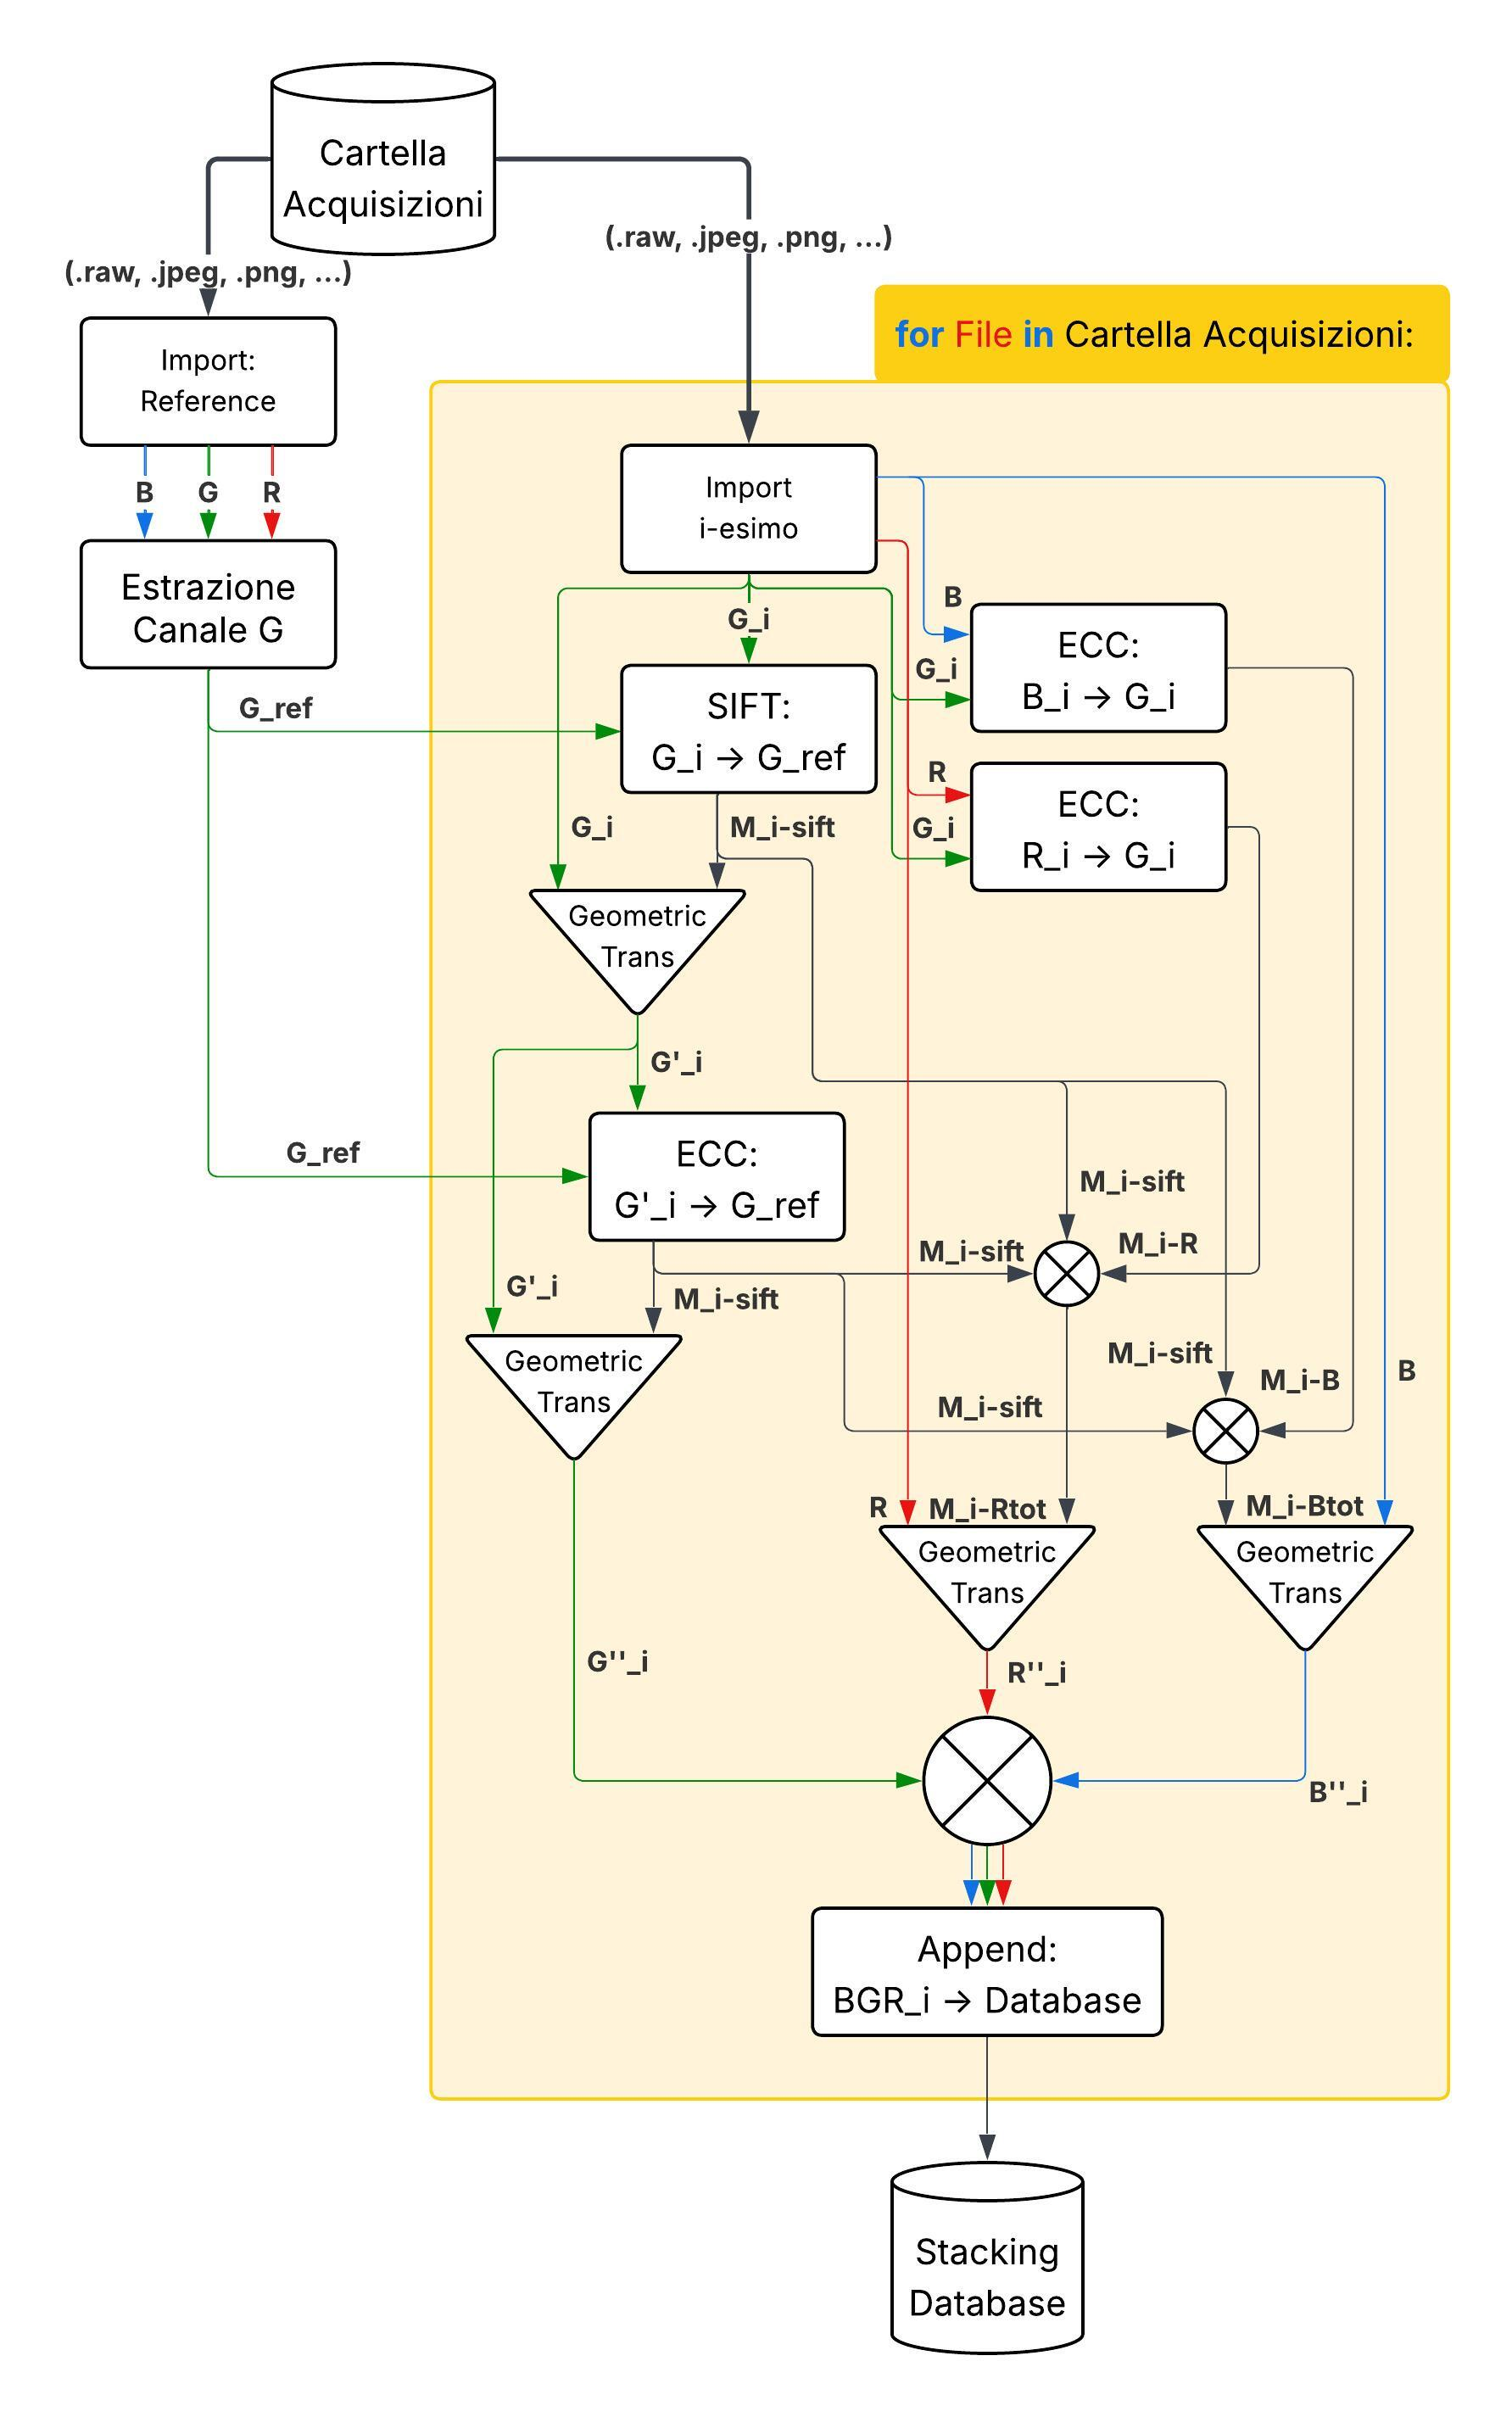

In [36]:
from IPython import display
display.Image("Blank diagram.jpeg")

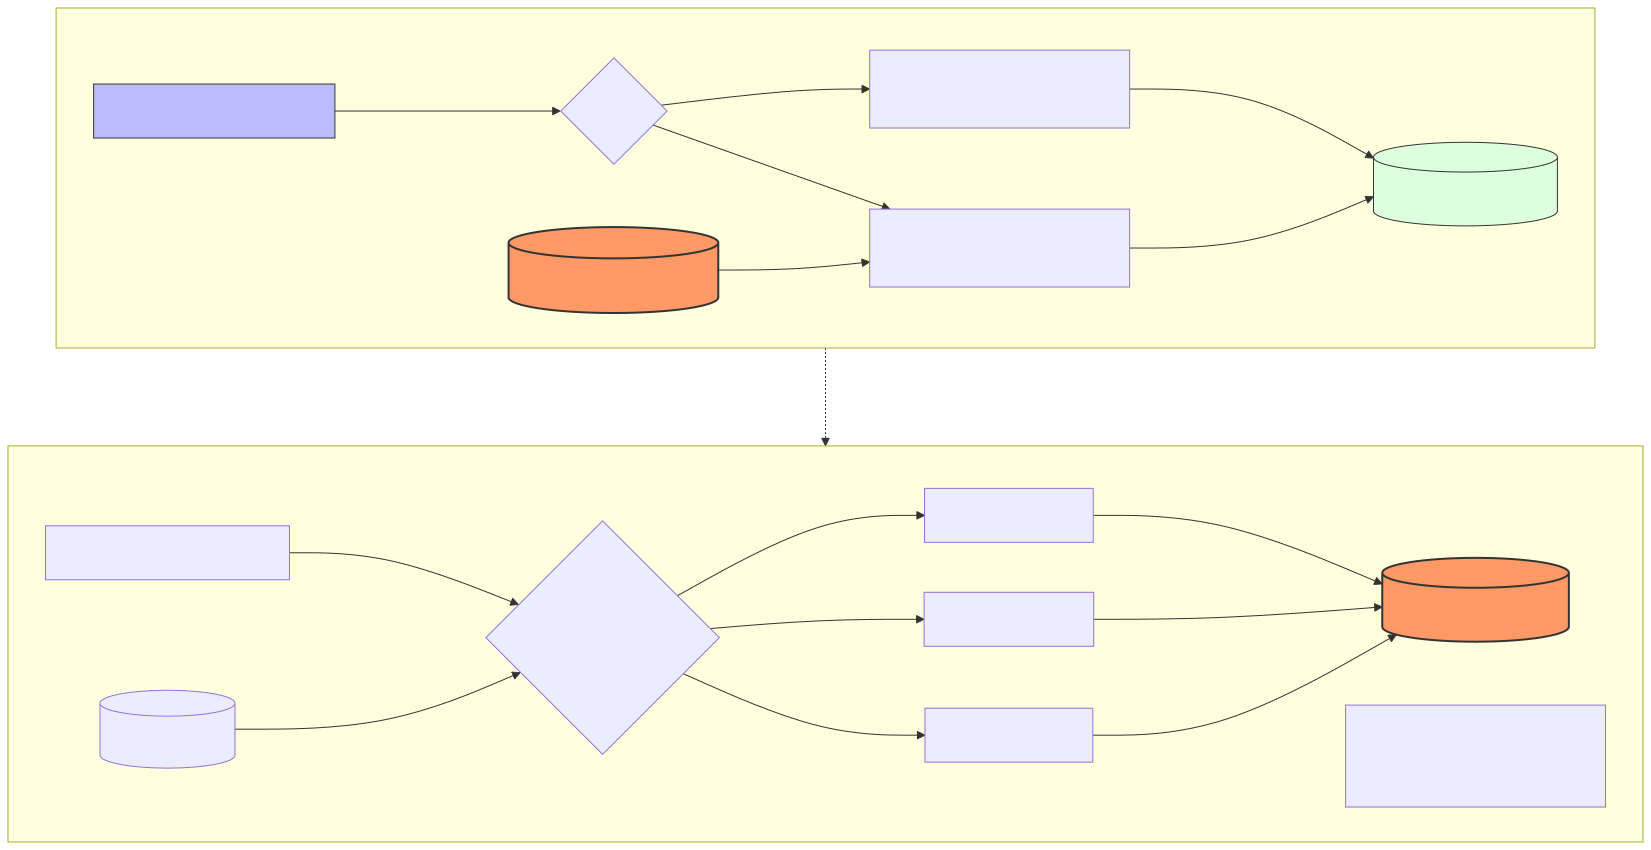

In [29]:
import base64
import io, requests
from IPython.display import Image, display
from PIL import Image as im
import matplotlib.pyplot as plt
from IPython.display import SVG, display

def mm(graph):
    graphbytes = graph.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    img = im.open(io.BytesIO(requests.get('https://mermaid.ink/img/' + base64_string).content))
    # DEFINISCI LA DIMENSIONE (es. 20x15 pollici)
    plt.figure(figsize=(20, 15)) 
    plt.imshow(img, interpolation='lanczos') # Interpolazione per miglior qualità
    plt.axis('off')
    # bbox_inches='tight' rimuove i bordi bianchi inutili
    plt.savefig('image.png', dpi=300, bbox_inches='tight')
    plt.show()

def mm_svg(graph):
    graphbytes = graph.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    
    # Cambia /img/ in /svg/
    url = 'https://mermaid.ink/svg/' + base64_string
    display(SVG(url=url))

mm_svg("""
graph TD
    %% Definizione Stili
    classDef memory fill:#f96,stroke:#333,stroke-width:2px;
    classDef process fill:#bbf,stroke:#333,stroke-width:1px;
    classDef storage fill:#dfd,stroke:#333,stroke-width:1px;

    subgraph Fase_1_Analisi [FASE 1: Analisi e Calcolo Matrici 1-a-1]
        REF[(Riferimento: Solo Canale G)]:::memory
        RAW_N[Caricamento Immagine N]:::process
        
        RAW_N -->|1. Split Canali| CHANNELS{R, G, B}
        
        CHANNELS -->|Solo R e B| ECC_INT[ECC Allineamento Canali Interni]
        CHANNELS -->|Solo G| ALIGN_GLOB[SIFT + ECC Allineamento tra Frame]
        
        REF -->|Target| ALIGN_GLOB
        
        ECC_INT -->|Matrici R->G, B->G| MAT_STORE
        ALIGN_GLOB -->|Matrice Globale M_glob| MAT_STORE[(Database Matrici e Pesi)]:::storage
    end

    subgraph Fase_2_Stacking [FASE 2: Stacking Drizzle 3x e Single-Pass]
        DB_MAT[(Database Matrici)]
        ACC_RGB[(Accumulatore 3x float64)]:::memory
        
        FILE_N[Nuovo caricamento File N] -->|Canali separati| WARP_OP
        DB_MAT -->|Recupero Matrici| WARP_OP{Calcolo Matrice Finale 3x}
        
        WARP_OP -->|M_glob x M_R->G| WR[Warp Canale R]
        WARP_OP -->|M_glob| WG[Warp Canale G]
        WARP_OP -->|M_glob x M_B->G| WB[Warp Canale B]
        
        WR -->|Single Pass Interpolation| ACC_RGB
        WG -->|Single Pass Interpolation| ACC_RGB
        WB -->|Single Pass Interpolation| ACC_RGB
        
        note1[L'Immagine N viene scartata dalla RAM dopo la somma]
    end

    %% Flussi di dati colorati (commentati logicamente)
    %% Rosso: Dati voluminosi (Immagini)
    %% Verde: Dati leggeri (Matrici/Float)
    
    Fase_1_Analisi -.->|Dati salvati: Matrici 2x3 + Peso| Fase_2_Stacking
""")

In [30]:
# External python packages
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import astroalign as aa
import os
import rawpy
from pathlib import Path
from PIL import Image
import gc
import imageio.v3 as iio
from skimage.restoration import richardson_lucy
from typing import Any
import pickle

# Cross references to other function libraries
from Functions_library import Conversion_functions as Conversions
from Functions_library import Import_functions as Imports

## Input Parameters setup and initialization

Here we want to set all the user defined variables in order to leave the rest of the code to the actual processing.

In [22]:
camera_acquisitions_folder = "C:/Users/filip/Desktop/Sessione_25-12-28/Orion 01/Foto all'ombra"
midsave_folder = "C:/Users/filip/Desktop/Sessione_25-12-28/Orion 01/Foto all'ombra/MidSaves"
input_format = ".dng" # Da usare se si vuole importare un formato nello specifico
output_format = ".tif" # Formato di output desiderato
processing_format = "float32" # Formato di elaborazione desiderato: "uint8", "uint16", "float32", "float64"
output_bit_depth = "uint16" # Profondità di bit di output desiderata: "uint8", "uint16", "float32"

life_in_the_fast_lane = True

## Initialization

The data is structured here to give a clear order and a tidy frame to store everything.

In particular we want to tag every image with the place it takes inside the whole list.
The single iamge will be characterized by:

* The File name 
* Its colored image, with the 3 BGR channels
* Its black and white image, used for the alignments
* All the transformations it underwent
* Some quality scoring

To keep the code fluid the single variables will be declared gradually

## Images Import

We will now actually import the images contained inside the specified folder.

The data structure can already be understood and the import result is stored inside a mid-save variable.

In [23]:
database = []
for file in Path(camera_acquisitions_folder).glob(f'*{input_format}'):
    try:
        data_element: dict[str, Any] = { 'file_path' : str(file) ,
                                         'bgr_image' : None      }
        data_element['bgr_image'] = Imports.general2bgr(str(file), processing_format)
        database.append(data_element)
        print(f"✅ Caricata immagine numero {len(database)}: {file}.")
    except Exception as e:
        print(f"❌ Errore nel caricamento dell'immagine {file}: {e}")
print(f"✅ Caricate {len(database)} immagini.")

if not life_in_the_fast_lane:
    # Salvataggio intermedio del database
    os.makedirs(midsave_folder, exist_ok=True)
    midasave_database = f"{midsave_folder}/Imported_images_database.pkl"
    with open(midasave_database, 'wb') as f:
        pickle.dump(database, f)
    print(f"✅ Database salvato in {midasave_database}.")

❌ Errore nel caricamento dell'immagine C:\Users\filip\Desktop\Sessione_25-12-28\Orion 01\Foto all'ombra\Lights_0001_20251228_234541.dng: __init__() got an unexpected keyword argument 'user_equal'
❌ Errore nel caricamento dell'immagine C:\Users\filip\Desktop\Sessione_25-12-28\Orion 01\Foto all'ombra\Lights_0002_20251228_234552.dng: __init__() got an unexpected keyword argument 'user_equal'
❌ Errore nel caricamento dell'immagine C:\Users\filip\Desktop\Sessione_25-12-28\Orion 01\Foto all'ombra\Lights_0003_20251228_234604.dng: __init__() got an unexpected keyword argument 'user_equal'
❌ Errore nel caricamento dell'immagine C:\Users\filip\Desktop\Sessione_25-12-28\Orion 01\Foto all'ombra\Lights_0004_20251228_234616.dng: __init__() got an unexpected keyword argument 'user_equal'
❌ Errore nel caricamento dell'immagine C:\Users\filip\Desktop\Sessione_25-12-28\Orion 01\Foto all'ombra\Lights_0005_20251228_234628.dng: __init__() got an unexpected keyword argument 'user_equal'
❌ Errore nel caricam

### Channels alignment

Now that we have all the images uploaded we want to start refining them.

The first step of data processing is to perferctly align the single color channels to have every star perfectly aligned with itself.

In [24]:
if not life_in_the_fast_lane:
    # Caricamento intermedio del database
    midsave_database = f"{midsave_folder}/Imported_images_database.pkl"
    with open(midsave_database, 'rb') as f:
        database = pickle.load(f)
    print(f"✅ Database caricato da {midsave_database} con {len(database)} immagini.")
# Now 'database' contains all imported images in BGR format with specified processing format

